Alright we've got features saved and ready to go. Time to do the fun bit. First up, we'll set up an evaluation framework that we can use for any sklearn model to make for easy comparison


In [30]:
import pandas as pd

train_df = pd.read_csv('data/train_features.csv')
test_df = pd.read_csv('data/test_features.csv')

print(train_df.shape)
print(test_df.shape)
print(train_df['genre'].value_counts())

(7985, 40)
(1996, 40)
genre
metal        880
reggae       850
rock         830
jazz         800
hiphop       799
pop          790
blues        780
country      779
disco        759
classical    718
Name: count, dtype: int64


In [31]:
# Splitting out features from the metadata
feature_cols = [c for c in train_df.columns if c not in ['genre', 'source_file', 'chunk_id']]

X_train = train_df[feature_cols].values
y_train = train_df['genre'].values

X_test = test_df[feature_cols].values
y_test = test_df['genre'].values

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Number of features: {len(feature_cols)}')

X_train shape: (7985, 37)
X_test shape: (1996, 37)
Number of features: 37


In [32]:
# Scaling everything to avoid models weighting some features more heavily than others using absolute values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only — never fit on test

print(f'Train mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Train std (should be ~1): {X_train_scaled.std():.4f}')

Train mean (should be ~0): -0.0000
Train std (should be ~1): 1.0000


In [33]:
# Encode the genre labels as numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f'Genres: {le.classes_}')
print(f'Encoded example: {y_train[0]} -> {y_train_encoded[0]}')

Genres: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Encoded example: pop -> 7


In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=789798
)

lr_model.fit(X_train_scaled, y_train_encoded)
print('Done!')

Done!


In [35]:
from sklearn.metrics import accuracy_score

y_pred = lr_model.predict(X_test_scaled)
acc = accuracy_score(y_test_encoded, y_pred)
print(f'Logistic Regression Accuracy: {acc:.4f}')

Logistic Regression Accuracy: 0.6478


Not bad for a first stab using a simple model. Much better than the baseline guessing which would give ~10% and roughly in line with GTZAN literature using logreg.

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.61      0.67      0.64       220
   classical       0.93      0.90      0.92       280
     country       0.55      0.51      0.53       218
       disco       0.58      0.46      0.52       240
      hiphop       0.63      0.56      0.59       199
        jazz       0.76      0.63      0.69       190
       metal       0.59      0.79      0.68       120
         pop       0.73      0.79      0.76       210
      reggae       0.62      0.74      0.68       150
        rock       0.35      0.40      0.37       169

    accuracy                           0.65      1996
   macro avg       0.64      0.65      0.64      1996
weighted avg       0.65      0.65      0.65      1996



Classical is easy which kinda makes sense, it's the most distinct genre out of these. Rock is harder - I assume it gets confused with things like metal, country, and blues an awful lot. We can see this with metal's high recall but low precision which indicates that some of the rock tracks are getting pulled in.

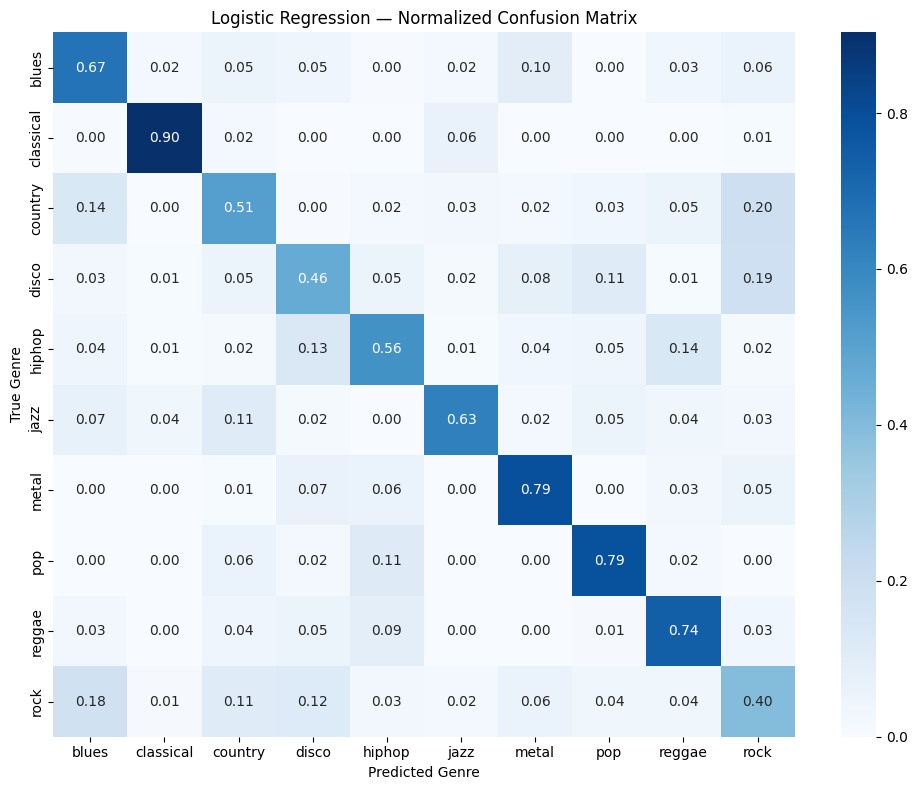

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('Logistic Regression — Normalized Confusion Matrix')
plt.ylabel('True Genre')
plt.xlabel('Predicted Genre')
plt.tight_layout()
plt.show()

Interesting, rock gets confused for blues, disco, and country mainly.

Generes like classical, pop, metal, and reggae all do very well. Makes sense as they're fairly distinct genres. Rock, country, disco, and blues all have lots of overlap and struggle a good deal more as they share a lot of musical elements. Not really a modeling failure - just a fact about our data. I'll be curious to see if other models also struggle in the same way.

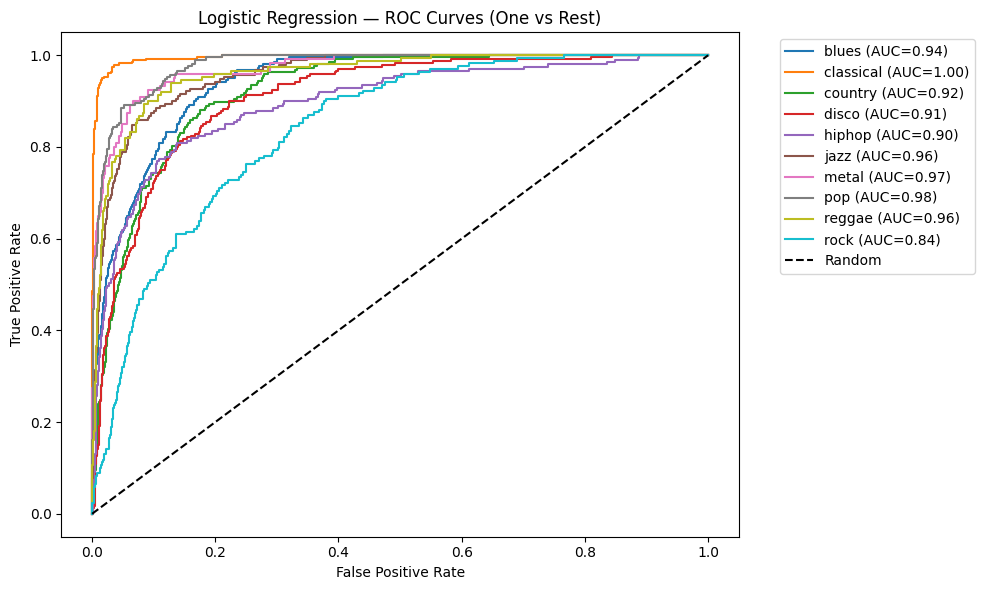

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test_encoded, classes=range(len(le.classes_)))
y_prob = lr_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 6))

for i, genre in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{genre} (AUC={auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — ROC Curves (One vs Rest)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_test_bin, 
    y_prob, 
    multi_class='ovr', 
    average='macro'
)
print(f'Logistic Regression Macro AUC: {macro_auc:.4f}')

Logistic Regression Macro AUC: 0.9370


AUC is better than accuracy across the board because the two metrics are asking fundamentally different things. Accuracy is a simple "was classical the mostly likely genre for this file". AUC asks "is the classical probability higher for actual classical tracks than for non-classical tracks?" It's a much softer question so the numbers are higher across the board. Accuracy penalizes uncertainty but AUC rewards consistent ranking.

In [40]:
# Saving results for later
lr_results = {
    'model': 'Logistic Regression',
    'accuracy': 0.6478,
    'macro_auc': 0.9370
}

Interpretability check

In [41]:
# Get the strongest coefficient per genre
top_features = {}
for genre in le.classes_:
    coeffs = coef_df.loc[genre]
    top_pos = coeffs.idxmax()
    top_neg = coeffs.idxmin()
    top_features[genre] = {
        'strongest positive': top_pos,
        'value': coeffs.max().round(3),
        'strongest negative': top_neg,
        'neg value': coeffs.min().round(3)
    }

pd.DataFrame(top_features).T

,strongest positive,value,strongest negative,neg value
blues,zcr_mean,2.415,spectral_centroid_mean,-3.078
classical,zcr_mean,1.648,mfcc1_mean,-2.709
country,mfcc1_mean,1.26,spectral_rolloff_mean,-1.249
disco,mfcc1_mean,2.295,spectral_centroid_mean,-2.271
hiphop,chroma_mean,2.301,mfcc2_mean,-2.108
jazz,spectral_centroid_mean,1.525,spectral_centroid_std,-1.896
metal,spectral_centroid_mean,2.361,rms_std,-1.855
pop,mfcc9_mean,1.604,mfcc4_mean,-1.332
reggae,spectral_centroid_mean,1.667,zcr_mean,-1.437
rock,mfcc1_mean,2.176,rms_std,-1.049


We can break this down later to see how they relate to music characteristics

In [17]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=46577698
)

svm_model.fit(X_train_scaled, y_train_encoded)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test_encoded, y_pred_svm)
print(f'SVM Accuracy: {acc_svm:.4f}')

SVM Accuracy: 0.7229


In [19]:
print(classification_report(y_test_encoded, y_pred_svm, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.70      0.75      0.73       220
   classical       0.91      0.96      0.93       280
     country       0.65      0.66      0.66       218
       disco       0.67      0.60      0.64       240
      hiphop       0.67      0.64      0.66       199
        jazz       0.83      0.74      0.79       190
       metal       0.66      0.86      0.74       120
         pop       0.80      0.80      0.80       210
      reggae       0.76      0.73      0.75       150
        rock       0.44      0.41      0.42       169

    accuracy                           0.72      1996
   macro avg       0.71      0.72      0.71      1996
weighted avg       0.72      0.72      0.72      1996



Clear improvement across the board.



In [21]:
comparison = pd.DataFrame({
    'Genre': ['blues', 'classical', 'country', 'disco', 'hiphop', 
              'jazz', 'metal', 'pop', 'reggae', 'rock'],
    'LR F1': [0.64, 0.92, 0.53, 0.52, 0.59, 0.69, 0.68, 0.76, 0.68, 0.37],
    'SVM F1': [0.73, 0.93, 0.66, 0.64, 0.66, 0.79, 0.74, 0.80, 0.75, 0.42],
})

comparison['Change'] = (comparison['SVM F1'] - comparison['LR F1']).round(2)
comparison['Change'] = comparison['Change'].apply(lambda x: f'+{x:.2f}' if x > 0 else f'{x:.2f}')

print(comparison.to_markdown(index=False))

| Genre     |   LR F1 |   SVM F1 |   Change |
|:----------|--------:|---------:|---------:|
| blues     |    0.64 |     0.73 |     0.09 |
| classical |    0.92 |     0.93 |     0.01 |
| country   |    0.53 |     0.66 |     0.13 |
| disco     |    0.52 |     0.64 |     0.12 |
| hiphop    |    0.59 |     0.66 |     0.07 |
| jazz      |    0.69 |     0.79 |     0.1  |
| metal     |    0.68 |     0.74 |     0.06 |
| pop       |    0.76 |     0.8  |     0.04 |
| reggae    |    0.68 |     0.75 |     0.07 |
| rock      |    0.37 |     0.42 |     0.05 |


The largest improvements are in country and disco but rock still struggles. Seems like the nonlinear boundaries are doing what they need to.

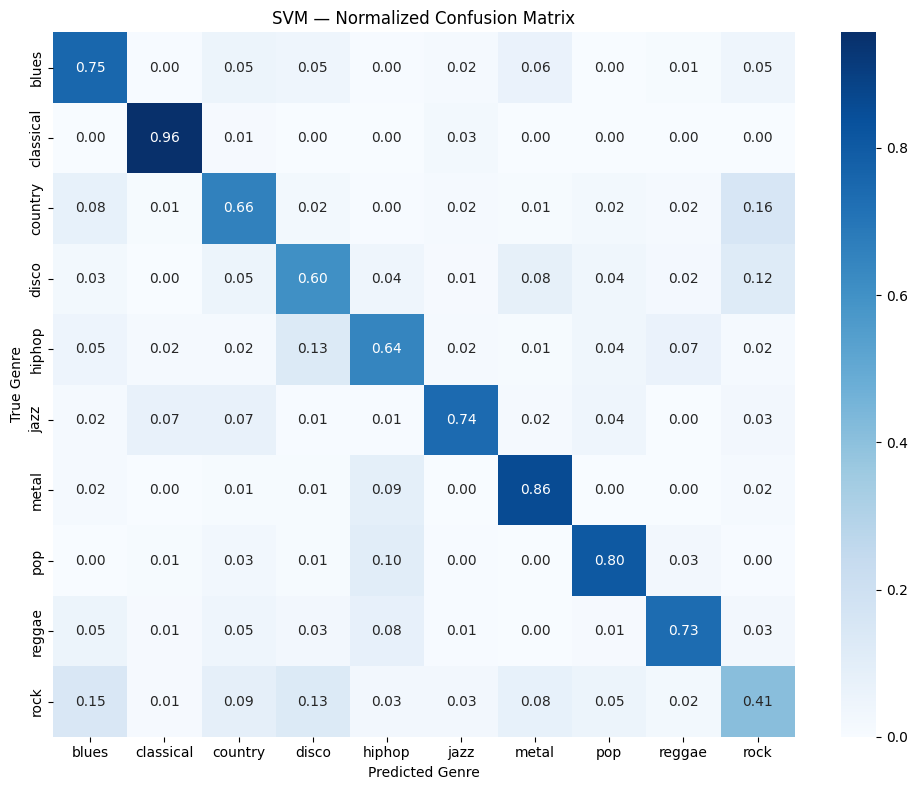

In [22]:
cm_svm = confusion_matrix(y_test_encoded, y_pred_svm, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='.2f',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('SVM — Normalized Confusion Matrix')
plt.ylabel('True Genre')
plt.xlabel('Predicted Genre')
plt.tight_layout()
plt.show()

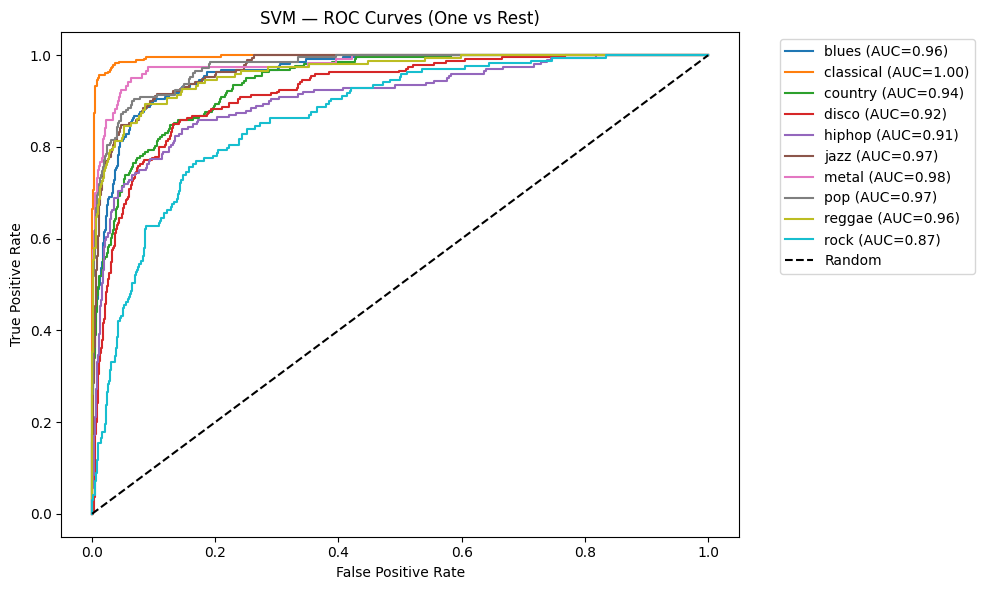

SVM Macro AUC: 0.9487


In [23]:
y_prob_svm = svm_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 6))

for i, genre in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob_svm[:, i])
    plt.plot(fpr, tpr, label=f'{genre} (AUC={auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM — ROC Curves (One vs Rest)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

macro_auc_svm = roc_auc_score(y_test_bin, y_prob_svm, multi_class='ovr', average='macro')
print(f'SVM Macro AUC: {macro_auc_svm:.4f}')

Let's do a little interpretability analysis quick

In [27]:
# Get the indices of support vectors in the training set
sv_indices = svm_model.support_

print(f'Total support vectors: {len(sv_indices)}')
print(f'As % of training set: {len(sv_indices)/len(X_train_scaled)*100:.1f}%')

# Look up which files and genres they came from
sv_df = train_df.iloc[sv_indices][['genre', 'source_file', 'chunk_id']]
print('\nSupport vectors per genre:')
print(sv_df['genre'].value_counts())

Total support vectors: 5524
As % of training set: 69.2%

Support vectors per genre:
genre
rock         745
disco        653
country      640
reggae       640
blues        597
hiphop       574
jazz         500
pop          448
metal        394
classical    333
Name: count, dtype: int64


Wow really interesting result. Almost 70% of the data set are support vectors which means the genres heavily overlap in feature space and we need lots of boundary points to define the decision surface. The rankings are clearly inversely proportional to classification performance which aligns with that understanding - an ambiguous genre needs more support vectors.

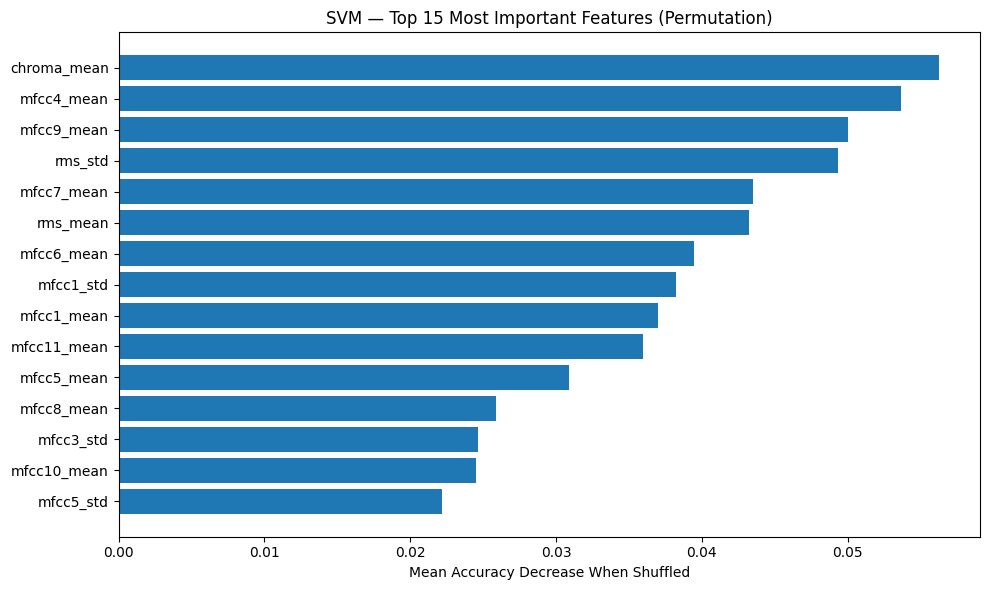

In [26]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    svm_model, 
    X_test_scaled, 
    y_test_encoded,
    n_repeats=10,
    random_state=42
)

# Put into a dataframe and sort
perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['feature'][::-1], perm_df['importance'][::-1])
plt.xlabel('Mean Accuracy Decrease When Shuffled')
plt.title('SVM — Top 15 Most Important Features (Permutation)')
plt.tight_layout()
plt.show()

In [42]:
svm_results = {
    'model': 'SVM (RBF)',
    'accuracy': 0.7229,
    'macro_auc': 0.9487
}

results = [lr_results, svm_results]

On to a simple neural network

In [44]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=8961923,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train_encoded)

Iteration 1, loss = 1.48423411
Iteration 2, loss = 0.98824918
Iteration 3, loss = 0.82786877
Iteration 4, loss = 0.73518404
Iteration 5, loss = 0.66432078
Iteration 6, loss = 0.60899890
Iteration 7, loss = 0.56064898
Iteration 8, loss = 0.52290511
Iteration 9, loss = 0.48652973
Iteration 10, loss = 0.45118214
Iteration 11, loss = 0.42378368
Iteration 12, loss = 0.39422205
Iteration 13, loss = 0.36533176
Iteration 14, loss = 0.34118830
Iteration 15, loss = 0.31979279
Iteration 16, loss = 0.29916564
Iteration 17, loss = 0.28292748
Iteration 18, loss = 0.26119500
Iteration 19, loss = 0.24547362
Iteration 20, loss = 0.22896033
Iteration 21, loss = 0.21842551
Iteration 22, loss = 0.20842708
Iteration 23, loss = 0.19342992
Iteration 24, loss = 0.17761790
Iteration 25, loss = 0.16911158
Iteration 26, loss = 0.16156251
Iteration 27, loss = 0.14589991
Iteration 28, loss = 0.14108007
Iteration 29, loss = 0.12707278
Iteration 30, loss = 0.12232565
Iteration 31, loss = 0.11480796
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",8961923


In [45]:
y_pred_mlp = mlp_model.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test_encoded, y_pred_mlp)
print(f'MLP Accuracy: {acc_mlp:.4f}')

MLP Accuracy: 0.6899


In [46]:
print(classification_report(y_test_encoded, y_pred_mlp, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.70      0.72      0.71       220
   classical       0.94      0.90      0.92       280
     country       0.62      0.60      0.61       218
       disco       0.63      0.60      0.62       240
      hiphop       0.62      0.65      0.63       199
        jazz       0.79      0.71      0.75       190
       metal       0.61      0.85      0.71       120
         pop       0.75      0.74      0.74       210
      reggae       0.72      0.66      0.69       150
        rock       0.42      0.43      0.43       169

    accuracy                           0.69      1996
   macro avg       0.68      0.69      0.68      1996
weighted avg       0.70      0.69      0.69      1996



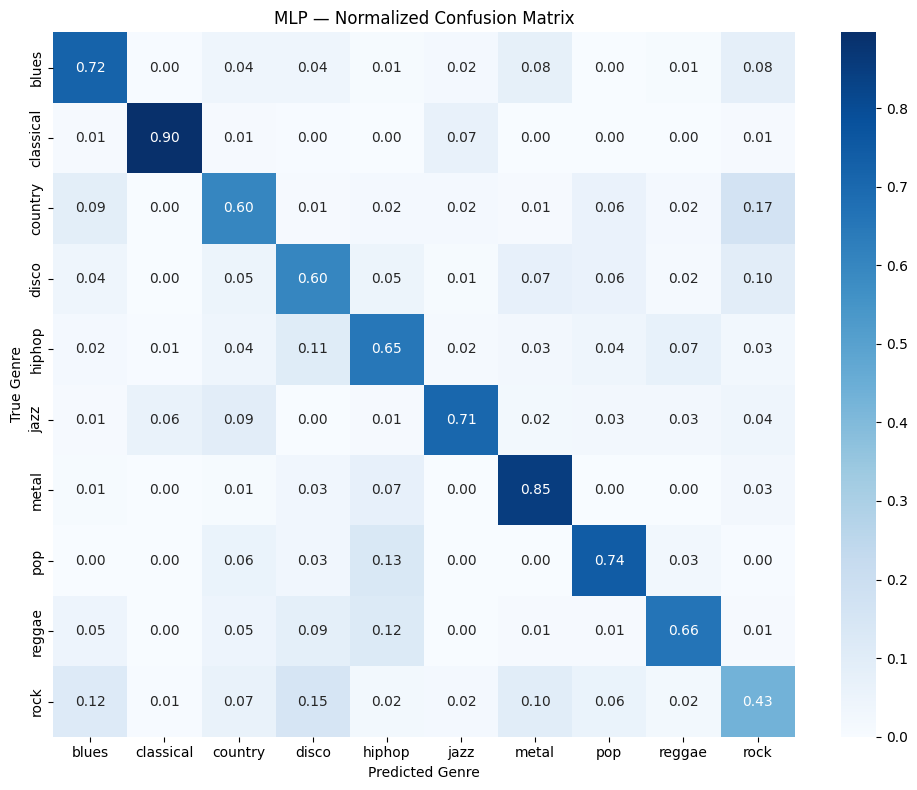

In [48]:
cm_mlp = confusion_matrix(y_test_encoded, y_pred_mlp, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='.2f',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('MLP — Normalized Confusion Matrix')
plt.ylabel('True Genre')
plt.xlabel('Predicted Genre')
plt.tight_layout()
plt.show()

Very similar to SVM across the board but pretty much strictly worse. Interesting result but makes sense given the limited size of the training data. Something like a CNN on the raw audio data might work a lot better than MLP on CNN, we can touch on this in the presentation as potential future work.

In [49]:
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)

macro_auc_mlp = roc_auc_score(y_test_bin, y_prob_mlp, multi_class='ovr', average='macro')
print(f'MLP Macro AUC: {macro_auc_mlp:.4f}')

MLP Macro AUC: 0.9384


In [51]:
mlp_results = {
    'model': 'MLP',
    'accuracy': 0.6899,
    'macro_auc': 0.9384
}

results = [lr_results, svm_results, mlp_results]

On to XGBoost which probably will be the best.

In [62]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=128379,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [63]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
print(f'XGBoost Accuracy: {acc_xgb:.4f}')

XGBoost Accuracy: 0.6969


Interesting! I fully expected XGBoost to have the best accuracy but SVM is better. Maybe partially due to the limited dataset size, partially due to poor hyperparameter tuning, but maybe the geometric model of SVM is just better on this use case. 

In [64]:
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.74      0.75      0.74       220
   classical       0.91      0.92      0.92       280
     country       0.66      0.67      0.66       218
       disco       0.67      0.60      0.63       240
      hiphop       0.63      0.59      0.61       199
        jazz       0.78      0.64      0.71       190
       metal       0.70      0.88      0.78       120
         pop       0.76      0.78      0.77       210
      reggae       0.71      0.67      0.69       150
        rock       0.35      0.44      0.39       169

    accuracy                           0.70      1996
   macro avg       0.69      0.69      0.69      1996
weighted avg       0.70      0.70      0.70      1996



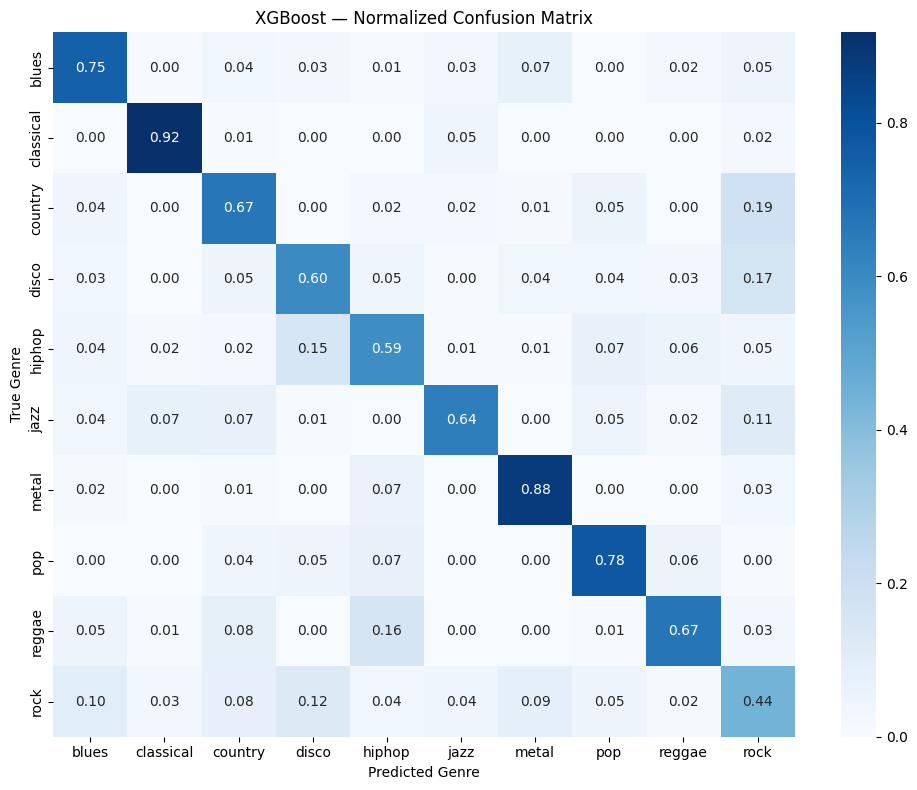

In [65]:
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='.2f',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('XGBoost — Normalized Confusion Matrix')
plt.ylabel('True Genre')
plt.xlabel('Predicted Genre')
plt.tight_layout()
plt.show()

In [66]:
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)
macro_auc_xgb = roc_auc_score(y_test_bin, y_prob_xgb, multi_class='ovr', average='macro')
print(f'XGBoost Macro AUC: {macro_auc_xgb:.4f}')

XGBoost Macro AUC: 0.9507


Huh it actually has the best AUC even though accuracy loses quite a bit to SVM. Seems like XGBoost is better at ranking consistently even though it doesn't always get the right answer.

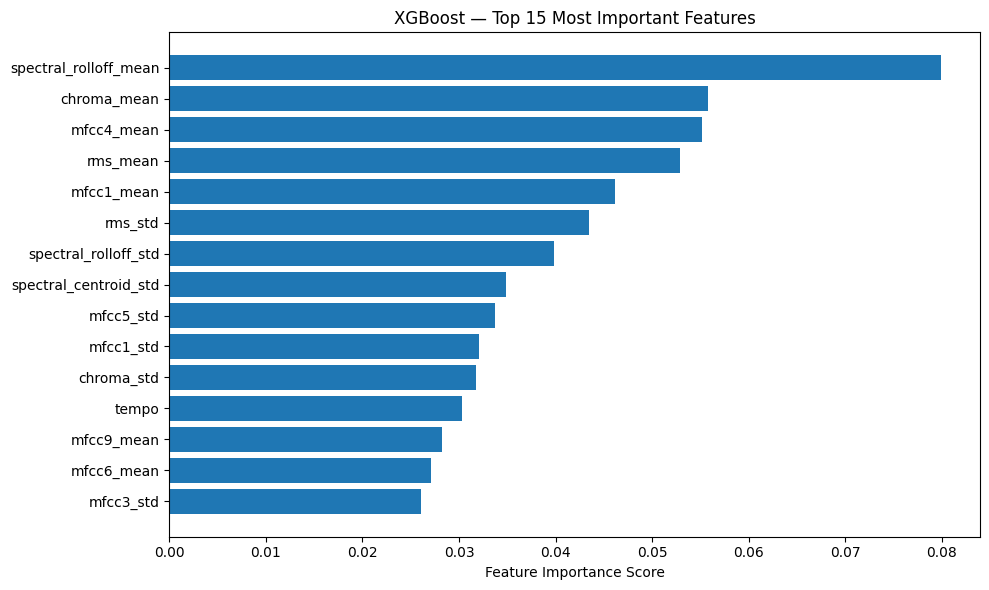

In [67]:
xgb_results = {
    'model': 'XGBoost',
    'accuracy': 0.6969,
    'macro_auc': 0.9507
}

results = [lr_results, svm_results, mlp_results, xgb_results]

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel('Feature Importance Score')
plt.title('XGBoost — Top 15 Most Important Features')
plt.tight_layout()
plt.show()

Rolloff matters a lot here when it didn't really with SVM. Pretty interesting, we can break that down in the slides.

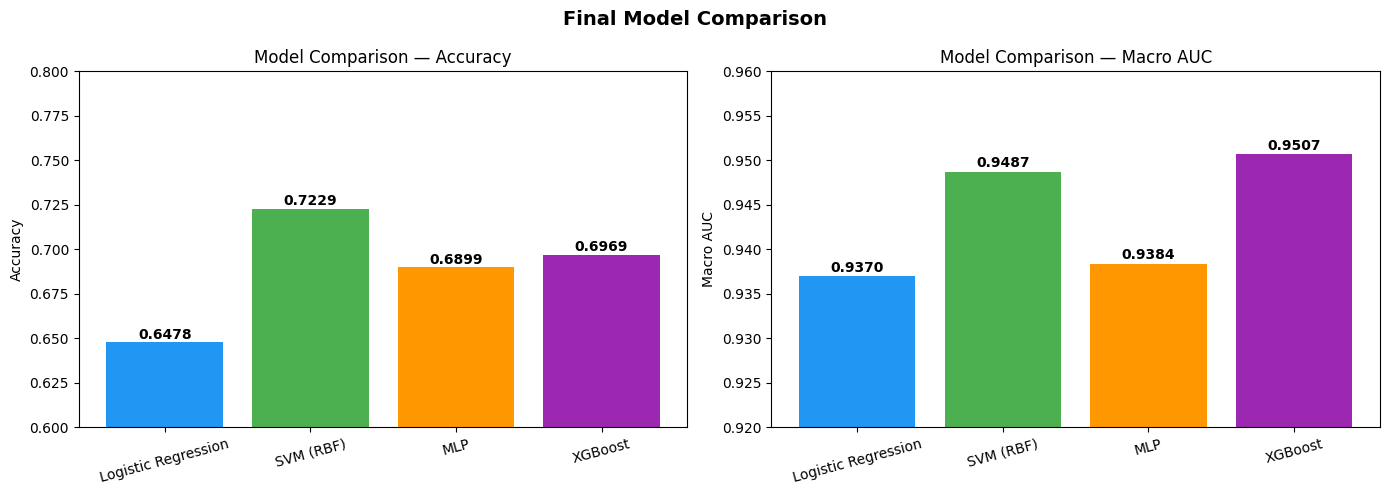

In [68]:
# Build final comparison dataframe
final_results = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.bar(final_results['model'], final_results['accuracy'], color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
ax1.set_title('Model Comparison — Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.6, 0.8)
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(final_results['accuracy']):
    ax1.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

# AUC comparison
ax2.bar(final_results['model'], final_results['macro_auc'], color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
ax2.set_title('Model Comparison — Macro AUC')
ax2.set_ylabel('Macro AUC')
ax2.set_ylim(0.92, 0.96)
ax2.tick_params(axis='x', rotation=15)
for i, v in enumerate(final_results['macro_auc']):
    ax2.text(i, v + 0.0005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Final Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

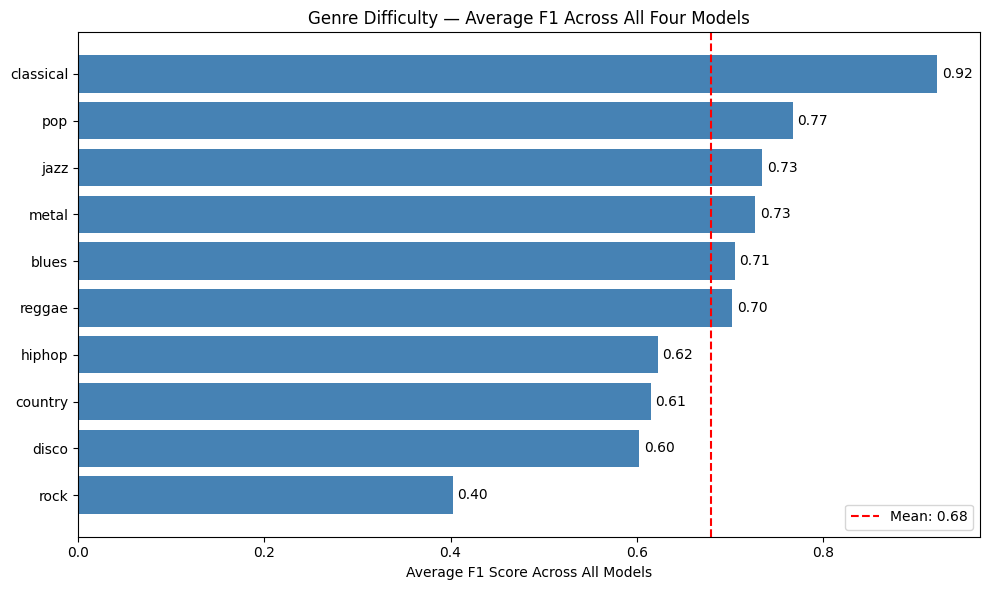

In [69]:
genre_f1 = {
    'blues':     [0.64, 0.73, 0.71, 0.74],
    'classical': [0.92, 0.93, 0.92, 0.92],
    'country':   [0.53, 0.66, 0.61, 0.66],
    'disco':     [0.52, 0.64, 0.62, 0.63],
    'hiphop':    [0.59, 0.66, 0.63, 0.61],
    'jazz':      [0.69, 0.79, 0.75, 0.71],
    'metal':     [0.68, 0.74, 0.71, 0.78],
    'pop':       [0.76, 0.80, 0.74, 0.77],
    'reggae':    [0.68, 0.75, 0.69, 0.69],
    'rock':      [0.37, 0.42, 0.43, 0.39],
}

avg_f1 = {genre: np.mean(scores) for genre, scores in genre_f1.items()}
avg_f1_df = pd.Series(avg_f1).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(avg_f1_df.index, avg_f1_df.values, color='steelblue')
plt.axvline(x=avg_f1_df.mean(), color='red', linestyle='--', label=f'Mean: {avg_f1_df.mean():.2f}')
plt.xlabel('Average F1 Score Across All Models')
plt.title('Genre Difficulty — Average F1 Across All Four Models')
plt.legend()
for bar, val in zip(bars, avg_f1_df.values):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}', va='center')
plt.tight_layout()
plt.show()

More we could do for sure but this will do given the time left. Lots of good visuals that should make for a solid presentaiton.